In [ ]:
# Credit Card Fraud Detection using XGBoost

**Goal:** Detect fraudulent credit card transactions using XGBoost on a highly imbalanced dataset.

Credit card fraud detection is a binary classification problem. The main challenge is that fraudulent transactions are extremely rare compared with genuine transactions.

We will use **SMOTE** to handle class imbalance, **XGBoost** for classification, decision threshold tuning to improve fraud detection, and feature importance scores to interpret the model.

## Workflow

1. Download and load dataset
2. Explore the data
3. Analyze class imbalance
4. Separate features (X) and target (y)
5. Train/test split
6. Apply SMOTE to training data
7. Train XGBoost
8. Predict fraud probabilities
9. Tune the decision threshold
10. Evaluate the model
11. Analyze the confusion matrix
12. Interpret feature importance

In [ ]:
## Step 1 — Download and Load the Dataset

💡 **Why we do this:** Before training a fraud detection model, we need transaction data containing both genuine and fraudulent transactions.

We use the Kaggle Credit Card Fraud Detection dataset. The dataset contains 284,807 transactions, of which only 492 are fraudulent, making it a highly imbalanced classification problem.

🔧 **Function breakdown:**

- `kagglehub.dataset_download()` → downloads the dataset from Kaggle.
- `os.listdir()` → shows the downloaded files.
- `pd.read_csv()` → loads the CSV into a Pandas DataFrame.
- `df.head()` → displays the first five transactions.

In [1]:
!pip install -q kagglehub imbalanced-learn xgboost

import kagglehub
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve
)

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)
print("Files:", os.listdir(path))

df = pd.read_csv(os.path.join(path, "creditcard.csv"))

df.head()

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud
Files: ['creditcard.csv']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
## Step 2 — Explore the Data

💡 **Why we do this:** Before training the model, we need to understand the dataset, its dimensions, data types, statistical information, and missing values.

We also inspect the `Class` column because it tells us whether a transaction is genuine or fraudulent.

In [2]:
print("Shape:", df.shape)

display(df.head())

df.info()

display(df.describe().T)

print("Missing values:")
display(df.isnull().sum().sort_values(ascending=False).head(10))

print("Class distribution:")
display(df["Class"].value_counts())

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


Missing values:


,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


Class distribution:


,count
Class,
0,284315
1,492


In [ ]:
## Step 3 — Analyze Class Imbalance

💡 **Why we do this:** Fraudulent transactions are much rarer than genuine transactions. This creates a highly imbalanced dataset, where a model could achieve high accuracy simply by predicting almost every transaction as genuine.

We therefore need a technique such as **SMOTE** to give the model more examples of the minority fraud class during training.

Genuine transactions: 284315
Fraudulent transactions: 492

Fraud percentage: 0.1727485630620034


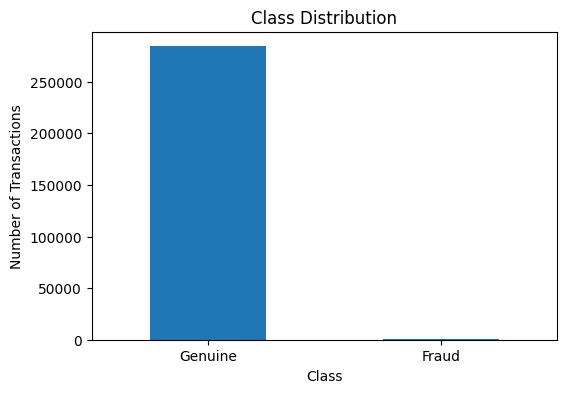

In [3]:
class_counts = df["Class"].value_counts()

print("Genuine transactions:", class_counts[0])
print("Fraudulent transactions:", class_counts[1])

print("\nFraud percentage:", (class_counts[1] / len(df)) * 100)

plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")
plt.title("Class Distribution")
plt.xticks([0, 1], ["Genuine", "Fraud"], rotation=0)
plt.show()

In [ ]:
## Step 4 — Separate Features and Target

💡 **Why we do this:** The `Class` column is our target variable. It tells us whether a transaction is fraudulent.

- `Class = 0` → Genuine transaction
- `Class = 1` → Fraudulent transaction

All other columns are used as input features for the XGBoost model.

In [4]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (284807, 30)
y shape: (284807,)


In [ ]:
## Step 5 — Split the Data into Training and Testing Sets

💡 **Why we do this:** We train XGBoost on the training data and evaluate it on unseen test data.

We use an 80/20 split. `stratify=y` keeps the same proportion of fraudulent and genuine transactions in both sets.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 227845
Testing samples: 56962


In [ ]:
## Step 6 — Apply SMOTE to the Training Data

💡 **Why we do this:** The fraud class is much smaller than the genuine class. SMOTE (Synthetic Minority Over-sampling Technique) creates synthetic examples of the minority class to reduce the imbalance.

We apply SMOTE **only to the training data**. The test data must remain unchanged so that evaluation represents the original real-world distribution.

🔧 **Function breakdown:**

- `SMOTE()` → creates synthetic minority-class samples.
- `fit_resample()` → learns the training data distribution and generates new samples.

In [6]:
smote = SMOTE(sampling_strategy=0.2, random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1     45490
Name: count, dtype: int64


In [ ]:
## Step 7 — Train the XGBoost Model

💡 **Why we do this:** XGBoost is a powerful tree-based machine learning algorithm that works well for classification problems. It can learn complex relationships between transaction features and fraud.

We train the model using the SMOTE-balanced training data.

In [7]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train_smote, y_train_smote)

print("XGBoost training completed!")

XGBoost training completed!


In [ ]:
## Step 8 — Predict Fraud Probabilities

💡 **Why we do this:** Instead of immediately predicting fraud or genuine, we first obtain the probability that each transaction is fraudulent.

This probability will later allow us to **tune the decision threshold** instead of automatically using 0.5.

- `0` → Genuine
- `1` → Fraud

In [8]:
y_prob = model.predict_proba(X_test)[:, 1]

display(pd.DataFrame({
    "Actual": y_test.values,
    "Fraud Probability": y_prob
}).head(10))

,Actual,Fraud Probability
0,0,0.000105
1,0,0.000004
2,0,0.000088
3,0,0.000005
4,0,0.000527
5,0,0.000119
6,0,0.000008
7,0,0.000027
8,0,0.000038
9,0,0.000021


In [ ]:
## Step 9 — Evaluate the Model using ROC-AUC and PR-AUC

💡 **Why we do this:** ROC-AUC measures how well the model separates fraudulent and genuine transactions.

Because fraud detection is highly imbalanced, **PR-AUC (Average Precision)** is also useful because it focuses more directly on the performance of the minority fraud class.

In [9]:
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

ROC-AUC: 0.9793528131567765
PR-AUC: 0.87696282163592


In [ ]:
## Step 10 — Tune the Decision Threshold

💡 **Why we do this:** A default threshold of 0.5 may not be ideal for fraud detection. Since missing a fraudulent transaction can be costly, we test different thresholds and select the one that gives the best F1-score.

The F1-score balances **precision** and **recall**.

In [10]:
thresholds = np.arange(0.1, 0.91, 0.05)

results = []

for threshold in thresholds:
    y_pred_temp = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_temp, zero_division=0)
    recall = recall_score(y_test, y_pred_temp, zero_division=0)
    f1 = f1_score(y_test, y_pred_temp, zero_division=0)

    results.append([threshold, precision, recall, f1])

threshold_results = pd.DataFrame(
    results,
    columns=["Threshold", "Precision", "Recall", "F1-Score"]
)

display(threshold_results)

best_threshold = threshold_results.loc[
    threshold_results["F1-Score"].idxmax(), "Threshold"
]

print("Best Threshold:", best_threshold)

,Threshold,Precision,Recall,F1-Score
0,0.10,0.425837,0.908163,0.579805
1,0.15,0.508876,0.877551,0.644195
2,0.20,0.569536,0.877551,0.690763
3,0.25,0.611511,0.867347,0.717300
4,0.30,0.648855,0.867347,0.742358
5,0.35,0.691057,0.867347,0.769231
6,0.40,0.705882,0.857143,0.774194
7,0.45,0.743363,0.857143,0.796209
8,0.50,0.763636,0.857143,0.807692
9,0.55,0.763636,0.857143,0.807692


Best Threshold: 0.9000000000000002


In [ ]:
## Step 11 — Evaluate using the Tuned Threshold

💡 **Why we do this:** Now we use the best threshold found in the previous step instead of the default 0.5 threshold.

This allows the model to classify transactions as fraudulent using a threshold that provides a better balance between precision and recall.

In [11]:
y_pred = (y_prob >= best_threshold).astype(int)

print("Threshold:", best_threshold)
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Threshold: 0.9000000000000002
Precision: 0.9111111111111111
Recall: 0.8367346938775511
F1-Score: 0.8723404255319149

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.91      0.84      0.87        98

    accuracy                           1.00     56962
   macro avg       0.96      0.92      0.94     56962
weighted avg       1.00      1.00      1.00     56962



In [ ]:
## Step 12 — Confusion Matrix

💡 **Why we do this:** The confusion matrix shows how many transactions were correctly and incorrectly classified.

- **True Positive (TP):** Fraud correctly detected
- **True Negative (TN):** Genuine transaction correctly identified
- **False Positive (FP):** Genuine transaction incorrectly flagged as fraud
- **False Negative (FN):** Fraudulent transaction missed by the model

For fraud detection, reducing false negatives is important because they represent fraudulent transactions that were not detected.

In [12]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()

print("\nTrue Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

Confusion Matrix:
[[56856     8]
 [   16    82]]

True Negatives: 56856
False Positives: 8
False Negatives: 16
True Positives: 82


In [ ]:
## Step 13 — Feature Importance

💡 **Why we do this:** XGBoost can tell us which features contributed most to its predictions.

Higher feature importance means that the feature was more useful to the model when making decisions.

This helps us interpret which transaction characteristics are most influential in detecting fraud.

In [13]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance.head(20))

,Feature,Importance
14,V14,0.608817
10,V10,0.090365
12,V12,0.046765
4,V4,0.043161
17,V17,0.030856
3,V3,0.012458
8,V8,0.012236
1,V1,0.011108
13,V13,0.009684
16,V16,0.009637


In [ ]:
## Step 14 — Plot Feature Importance

# The following graph shows the most important features used by the XGBoost model for fraud detection.

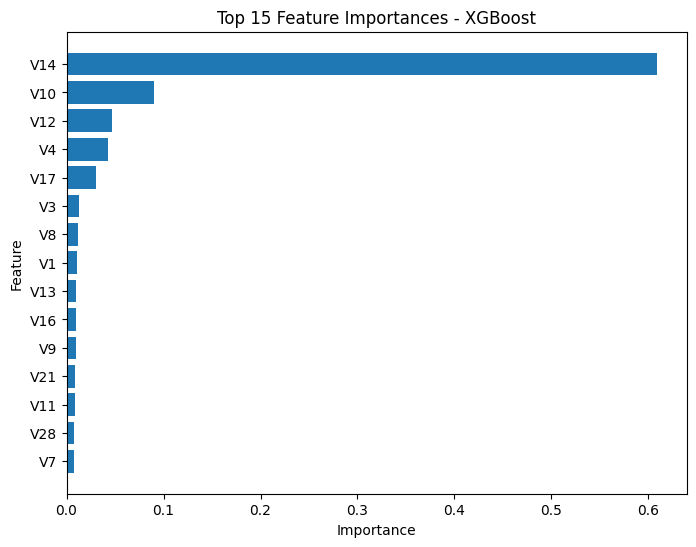

In [14]:
top_features = feature_importance.head(15)

plt.figure(figsize=(8, 6))
plt.barh(top_features["Feature"][::-1], top_features["Importance"][::-1])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - XGBoost")
plt.show()

In [ ]:
# ## Final Conclusion

# The XGBoost model was used to detect fraudulent credit card transactions in a highly imbalanced dataset.

# SMOTE was applied only to the training data to increase the representation of fraudulent transactions. The model produced fraud probabilities, and the decision threshold was tuned using the F1-score to balance precision and recall.

# Feature importance scores from XGBoost were used to identify the most influential transaction features.

# For fraud detection, reducing false negatives is particularly important because a false negative represents a fraudulent transaction that was missed.

# ### Final Pipeline

# Dataset → EDA → Class Imbalance Analysis → X/y Separation → Train/Test Split → SMOTE → XGBoost → Fraud Probability → Threshold Tuning → Evaluation → Confusion Matrix → Feature Importance

In [16]:
## Case Study Summary

### Hospital Readmission Prediction
# - Algorithm: Logistic Regression
# - Regularization: L2
# - Evaluation: ROC-AUC
# - Important consideration: False Negative vs False Positive cost

# ### Credit Card Fraud Detection
# - Algorithm: XGBoost
# - Imbalance Handling: SMOTE
# - Threshold: Tuned using F1-score
# - Interpretation: Feature Importance